**Мама**

$$
\int\limits_a^bf(x)=F(b)-F(a)
$$

[*********************100%***********************]  1 of 1 completed


Дневная волатильность: 0.01659778677340088
Годовая волатильность: 0.2634816966989754
Годовая волатильность в процентах: 26.34816966989754


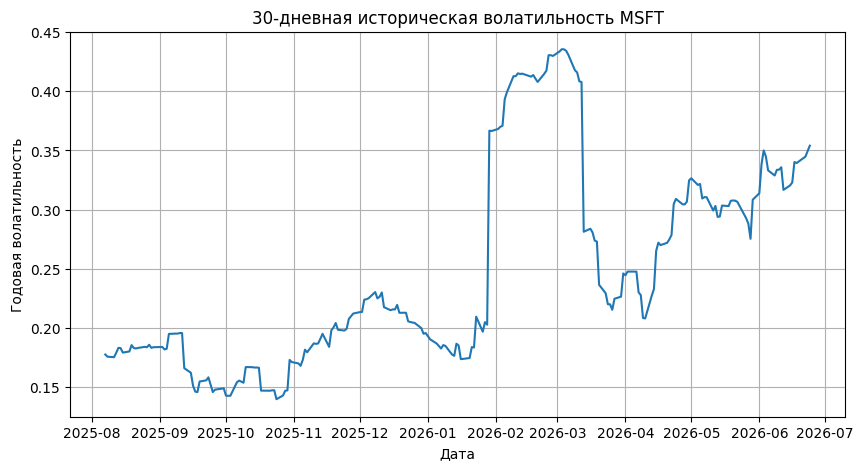

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

ticker = "MSFT"

# Берем примерно 1 год дневных данных
data = yf.download(ticker, period="1y", interval="1d", auto_adjust=True)

# Цена закрытия
data["log_return"] = np.log(data["Close"] / data["Close"].shift(1))

# Дневная волатильность
daily_vol = data["log_return"].std()

# Годовая волатильность
annual_vol = daily_vol * np.sqrt(252)

print("Дневная волатильность:", daily_vol)
print("Годовая волатильность:", annual_vol)
print("Годовая волатильность в процентах:", annual_vol * 100)

# Скользящая 30-дневная волатильность
data["rolling_vol_30"] = data["log_return"].rolling(30).std() * np.sqrt(252)

plt.figure(figsize=(10, 5))
plt.plot(data.index, data["rolling_vol_30"])
plt.title("30-дневная историческая волатильность MSFT")
plt.xlabel("Дата")
plt.ylabel("Годовая волатильность")
plt.grid(True)
plt.show()